In [1]:
# Load Libreries..
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [7]:
data = pd.read_csv("Advertising.csv")     # Load Dataset 
data = data.drop(columns = "Unnamed: 0",axis=True)

In [8]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [9]:
data.isnull().sum()   # Missing Value 

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


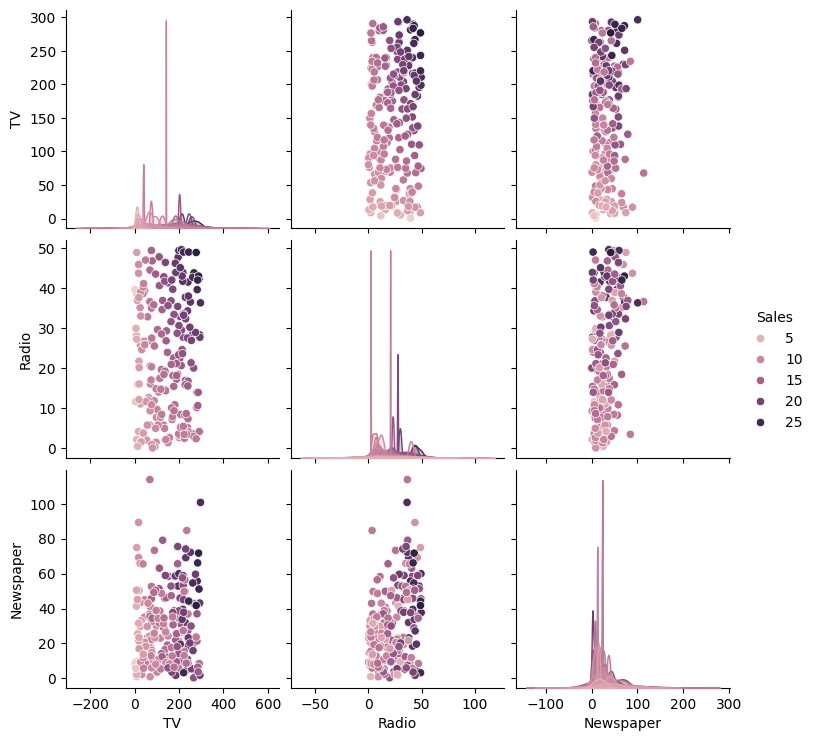

In [14]:
# Look the Pair Chart Compairation by sales.

sns.pairplot(data,hue = "Sales")
plt.show()

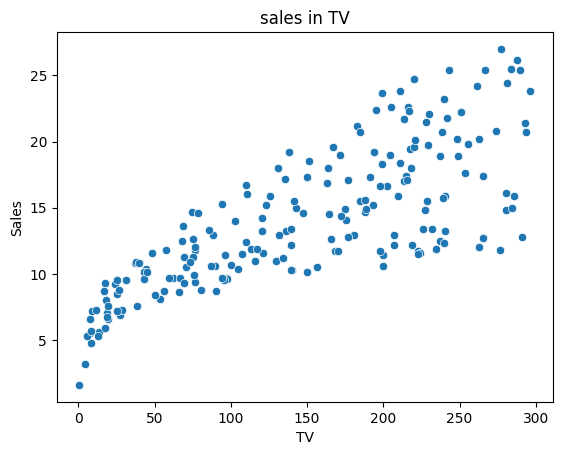

In [17]:
# Look the Scatter chart of TV with Sales

sns.scatterplot(x="TV",y="Sales",data= data)
plt.title("sales in TV")
plt.show()

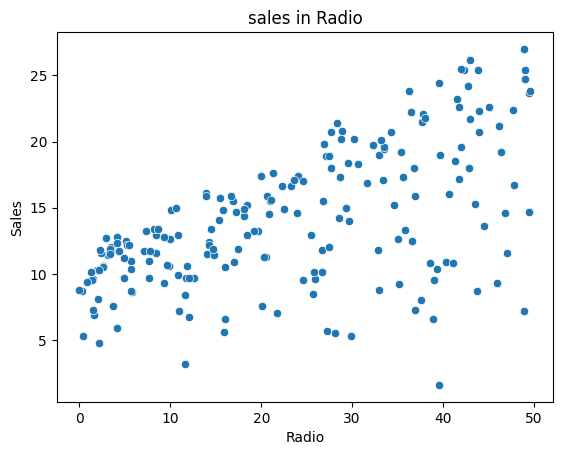

In [20]:
# Look the Scatter chart of Radio with Sales

sns.scatterplot(x="Radio",y="Sales",data= data)
plt.title("sales in Radio")
plt.show()

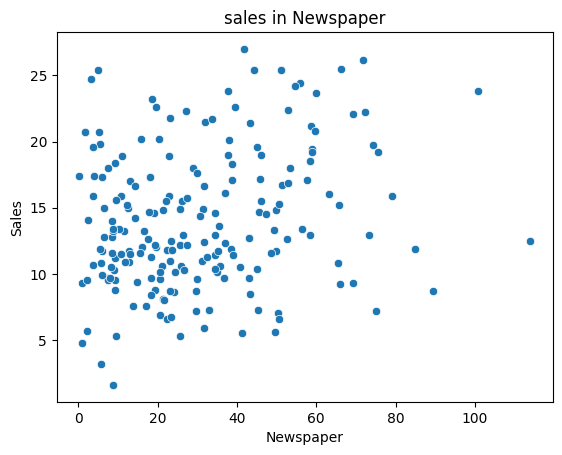

In [21]:
# Look the Scatter chart of Newspaper with Sales

sns.scatterplot(x="Newspaper",y="Sales",data= data)
plt.title("sales in Newspaper")
plt.show()

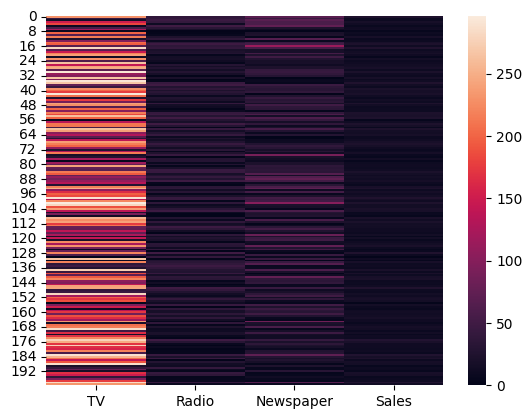

In [24]:
# look the heat Chart 
sns.heatmap(data)
plt.show()

In [25]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [26]:
# divide the dataset X AND Y Form for training data
x = data.iloc[:,:-1]
y = data[["Sales"]]

In [27]:
# import model --> Train Test Split
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2) # load model

In [29]:
# import 1st model --> LinearRegression
from sklearn.linear_model import LinearRegression

In [30]:
lr = LinearRegression()  # load model
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# find Accuracy of Train and Test
lr.score(x_test,y_test)*100,lr.score(x_train,y_train)*100   

(89.9438024100912, 89.57008271017818)

In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [35]:
r2_score(y_test,lr.predict(x_test))*100   # R2 score 

89.9438024100912

In [40]:
import numpy as np
mae = mean_absolute_error(y_test,lr.predict(x_test))*100
mse = np.sqrt(mean_squared_error(y_test,lr.predict(x_test))*100)

In [41]:
print(mse)  # mean_squared_error

17.815996615334498


In [42]:
print(mae)  # mean_absolute_error

146.07567168117603


In [43]:
#import 2nd model --> RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

In [44]:
rfr = RandomForestRegressor(random_state=42)  # load model
rfr.fit(x_train,y_train)

C:\Users\Lenovo\ml_env\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
# find Accuracy of Train and Test
rfr.score(x_test,y_test)*100,rfr.score(x_train,y_train)*100  

(98.12843792541844, 99.63471037158416)

In [47]:
r2_score(y_test,rfr.predict(x_test))*100    # Accuracy

98.12843792541844

In [48]:
mae = mean_absolute_error(y_test,rfr.predict(x_test))*100
mse = np.sqrt(mean_squared_error(y_test,rfr.predict(x_test))*100)

In [49]:
print(mae)  # mean_absolute_error

62.00999999999988


In [50]:
print(mse)   # mean_squared_error 

7.685910811348248


In [ ]:
#       model                  Accuracy(text)       Accuracy(train)               MAE                    MSE
1.   LinearRegression  -     89.9438024100912      89.57008271017818        146.07567168117603      17.815996615334498
2.  RandomForestRegressor -  98.12843792541844     99.63471037158416         62.00999999999988       7.685910811348248  

Linear Regression And RandomForestRegressor performed best based on the test accuracy And metrics And mean_absolute_error, mean_squared_error.
Therefore, it was selected as the best-performing model.